
# Name: Otu Samuel Jacob
Student ID: S25007038

# Install dependencies

In [4]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost imbalanced-learn

# Imports

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay)
import warnings
warnings.filterwarnings('ignore')

print("All libraries loaded successfully ✓")

All libraries loaded successfully ✓


# Load the dataset

In [5]:
df = pd.read_csv('Churn_Modelling.csv')
print("Shape:", df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


# Explore the data (EDA)

In [6]:
print("=== Dataset Info ===")
print(df.info())
print("\n=== Missing Values ===")
print(df.isnull().sum())
print("\n=== Class Distribution ===")
print(df['Exited'].value_counts())
print(f"\nChurn rate: {df['Exited'].mean()*100:.1f}%")

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None

=== Missing Values ===
RowNumber          0
CustomerId         0
Su

# Churn distribution plot

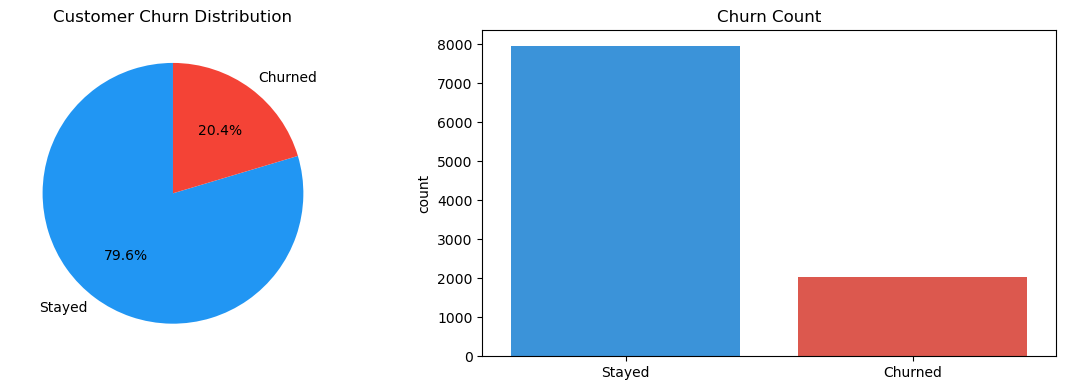

Plot saved ✓


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
axes[0].pie(df['Exited'].value_counts(),
            labels=['Stayed', 'Churned'],
            autopct='%1.1f%%',
            colors=['#2196F3', '#F44336'],
            startangle=90)
axes[0].set_title('Customer Churn Distribution')

# Count plot
sns.countplot(x='Exited', data=df, palette=['#2196F3', '#F44336'], ax=axes[1])
axes[1].set_xticklabels(['Stayed', 'Churned'])
axes[1].set_title('Churn Count')
axes[1].set_xlabel('')

plt.tight_layout()
plt.savefig('churn_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved ✓")

# Feature distributions by churn status

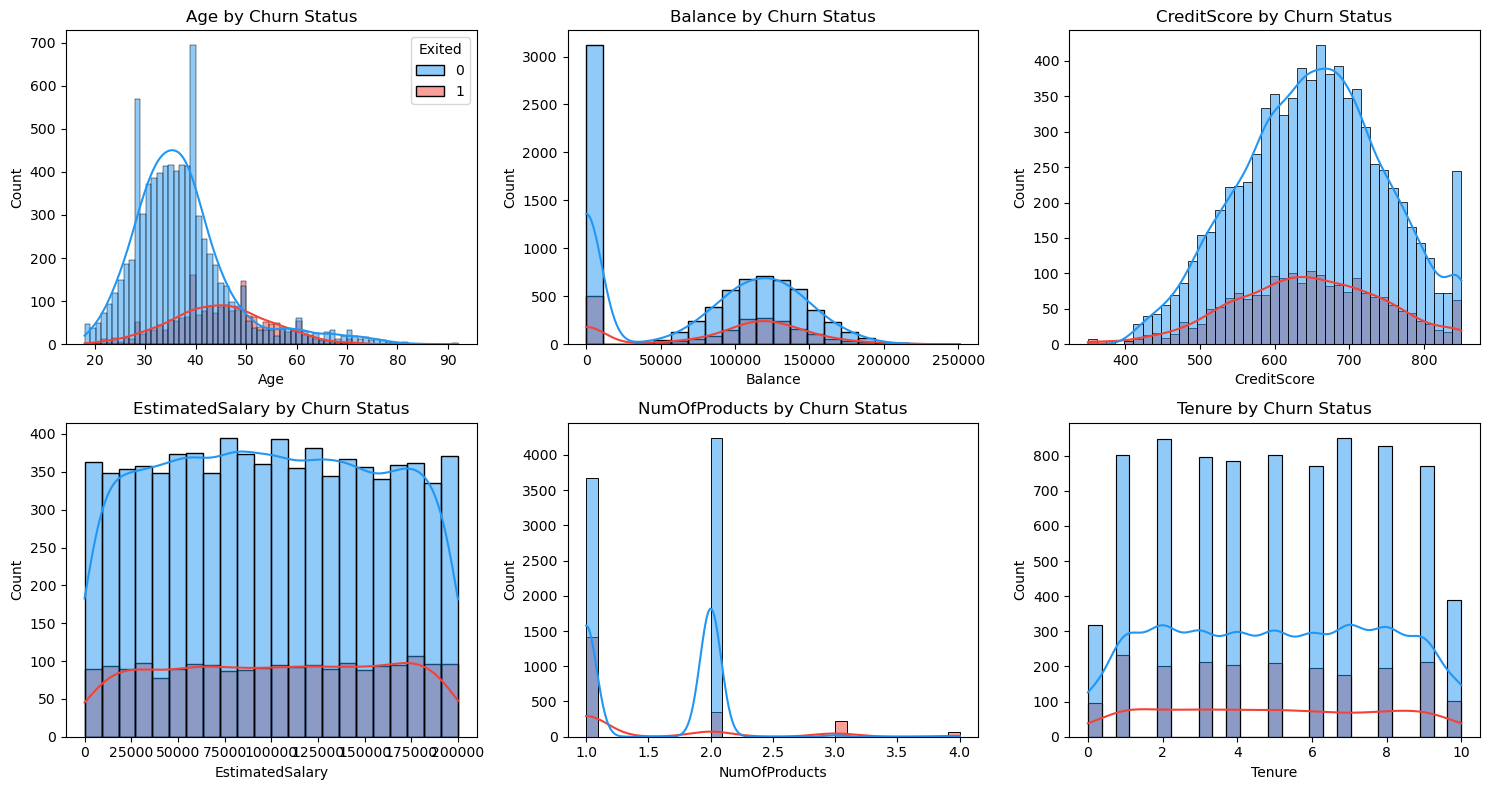

In [9]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
features = ['Age', 'Balance', 'CreditScore', 'EstimatedSalary', 'NumOfProducts', 'Tenure']

for ax, feat in zip(axes.flatten(), features):
    sns.histplot(data=df, x=feat, hue='Exited', kde=True,
                 palette=['#2196F3', '#F44336'], ax=ax, legend=(feat == 'Age'))
    ax.set_title(f'{feat} by Churn Status')

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Correlation heatmap

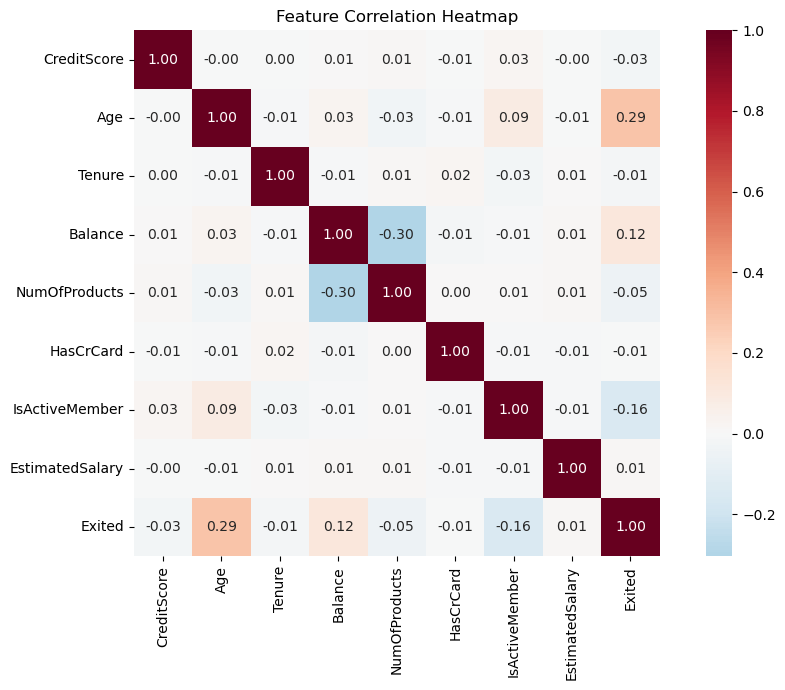

In [11]:
plt.figure(figsize=(10, 7))
numeric_df = df.select_dtypes(include=np.number).drop(
    columns=['RowNumber', 'CustomerId'])
sns.heatmap(numeric_df.corr(), annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, square=True)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Data Pipeline & Feature Engineering

# Drop columns that add no predictive value

In [20]:
print("Columns before cleaning:", df.columns.tolist())

df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], errors='ignore')

print("Columns after cleaning:", df.columns.tolist())

Columns before cleaning: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']
Columns after cleaning: ['CreditScore', 'Geography', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited']


# Encode Geography and Gender

In [23]:
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])        # Male=1, Female=0
df = pd.get_dummies(df, columns=['Geography'], drop_first=False)

print("Columns after encoding:")
print(df.columns.tolist())
df.head(3)

Columns after encoding:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France', 'Geography_Germany', 'Geography_Spain']


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,True,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,True,False,False


# Engineer new features
# Balance-to-salary ratio: a customer with high balance but low salary
# may be more engaged (or more at risk)

In [24]:
df['BalanceSalaryRatio'] = df['Balance'] / (df['EstimatedSalary'] + 1)

# Is the customer active AND has a credit card? Combined signal
df['ActiveWithCard'] = df['IsActiveMember'] * df['HasCrCard']

# Zero balance flag — customers with £0 balance may be disengaged
df['ZeroBalance'] = (df['Balance'] == 0).astype(int)

# Age group buckets — churn risk varies by life stage
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[0, 30, 45, 60, 100],
                         labels=[0, 1, 2, 3]).astype(int)

print("New features added:")
print(['BalanceSalaryRatio', 'ActiveWithCard', 'ZeroBalance', 'AgeGroup'])
print("\nFull feature list:", df.drop(columns='Exited').columns.tolist())

New features added:
['BalanceSalaryRatio', 'ActiveWithCard', 'ZeroBalance', 'AgeGroup']

Full feature list: ['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'BalanceSalaryRatio', 'ActiveWithCard', 'ZeroBalance', 'AgeGroup']


# Visualise class imbalance

Class distribution:
Exited
0    7963
1    2037
Name: count, dtype: int64

Imbalance ratio: 3.9:1


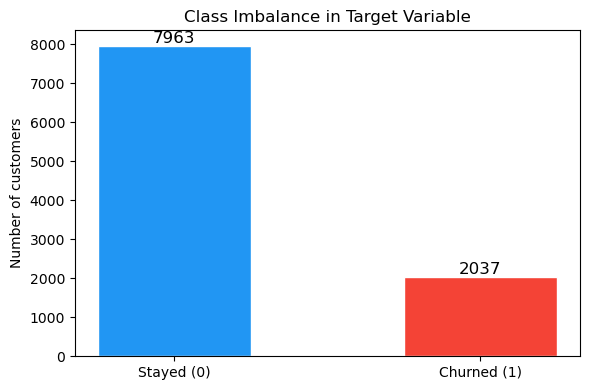

In [26]:
churn_counts = df['Exited'].value_counts()
print("Class distribution:")
print(churn_counts)
print(f"\nImbalance ratio: {churn_counts[0]/churn_counts[1]:.1f}:1")

# Plot
plt.figure(figsize=(6, 4))
bars = plt.bar(['Stayed (0)', 'Churned (1)'],
               churn_counts.values,
               color=['#2196F3', '#F44336'],
               edgecolor='white', width=0.5)
for bar, count in zip(bars, churn_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 80,
             str(count), ha='center', fontsize=12)
plt.title('Class Imbalance in Target Variable')
plt.ylabel('Number of customers')
plt.tight_layout()
plt.savefig('class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()

# Split X and y

In [28]:
X = df.drop(columns='Exited')
y = df['Exited']

# 80% train, 20% test — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Training set:  {X_train.shape}")
print(f"Test set:      {X_test.shape}")
print(f"\nTrain churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")

Training set:  (8000, 16)
Test set:      (2000, 16)

Train churn rate: 20.4%
Test churn rate:  20.3%


# Apply SMOTE to training data only

Before SMOTE: {0: 6370, 1: 1630}
After SMOTE:  {1: 6370, 0: 6370}


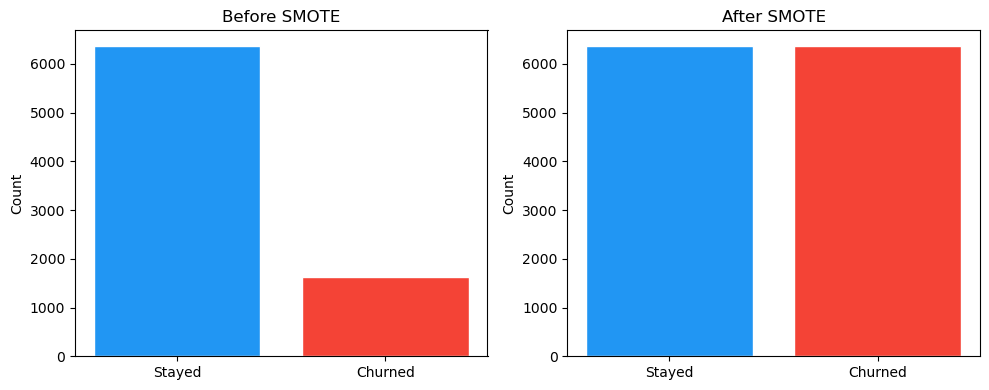

In [29]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", y_train.value_counts().to_dict())
print("After SMOTE: ", pd.Series(y_train_bal).value_counts().to_dict())

# Visualise
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (counts, title) in zip(axes, [
    (y_train.value_counts(), 'Before SMOTE'),
    (pd.Series(y_train_bal).value_counts(), 'After SMOTE')
]):
    ax.bar(['Stayed', 'Churned'], counts.values,
           color=['#2196F3', '#F44336'], edgecolor='white')
    ax.set_title(title)
    ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# Standardise numerical features

In [30]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled  = scaler.transform(X_test)

print("Scaling complete ✓")
print(f"Training mean (first feature): {X_train_scaled[:,0].mean():.4f}")
print(f"Training std  (first feature): {X_train_scaled[:,0].std():.4f}")

Scaling complete ✓
Training mean (first feature): -0.0000
Training std  (first feature): 1.0000


# Save scaler and feature names for deployment

In [31]:
import joblib

joblib.dump(scaler, 'scaler.pkl')
joblib.dump(X.columns.tolist(), 'feature_names.pkl')

print("Saved: scaler.pkl ✓")
print("Saved: feature_names.pkl ✓")
print("\nFeature names:")
print(X.columns.tolist())

Saved: scaler.pkl ✓
Saved: feature_names.pkl ✓

Feature names:
['CreditScore', 'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard', 'IsActiveMember', 'EstimatedSalary', 'Geography_France', 'Geography_Germany', 'Geography_Spain', 'BalanceSalaryRatio', 'ActiveWithCard', 'ZeroBalance', 'AgeGroup']


# Logistic Regression (baseline)

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train_bal)

# Predictions
lr_pred  = lr_model.predict(X_test_scaled)
lr_proba = lr_model.predict_proba(X_test_scaled)[:, 1]

print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred, target_names=['Stayed','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_proba):.4f}")

=== Logistic Regression ===
              precision    recall  f1-score   support

      Stayed       0.86      0.87      0.87      1593
     Churned       0.47      0.46      0.46       407

    accuracy                           0.78      2000
   macro avg       0.67      0.66      0.66      2000
weighted avg       0.78      0.78      0.78      2000

ROC-AUC: 0.7491


# Random Forest

In [33]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_model.fit(X_train_scaled, y_train_bal)

rf_pred  = rf_model.predict(X_test_scaled)
rf_proba = rf_model.predict_proba(X_test_scaled)[:, 1]

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred, target_names=['Stayed','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

      Stayed       0.90      0.88      0.89      1593
     Churned       0.56      0.63      0.59       407

    accuracy                           0.83      2000
   macro avg       0.73      0.75      0.74      2000
weighted avg       0.83      0.83      0.83      2000

ROC-AUC: 0.8517


# XGBoost

In [34]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)
xgb_model.fit(
    X_train_scaled, y_train_bal,
    eval_set=[(X_test_scaled, y_test)],
    verbose=False
)

xgb_pred  = xgb_model.predict(X_test_scaled)
xgb_proba = xgb_model.predict_proba(X_test_scaled)[:, 1]

print("=== XGBoost ===")
print(classification_report(y_test, xgb_pred, target_names=['Stayed','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

      Stayed       0.90      0.91      0.91      1593
     Churned       0.63      0.61      0.62       407

    accuracy                           0.85      2000
   macro avg       0.77      0.76      0.76      2000
weighted avg       0.85      0.85      0.85      2000

ROC-AUC: 0.8666


# Learning curves (evidence of debugging)

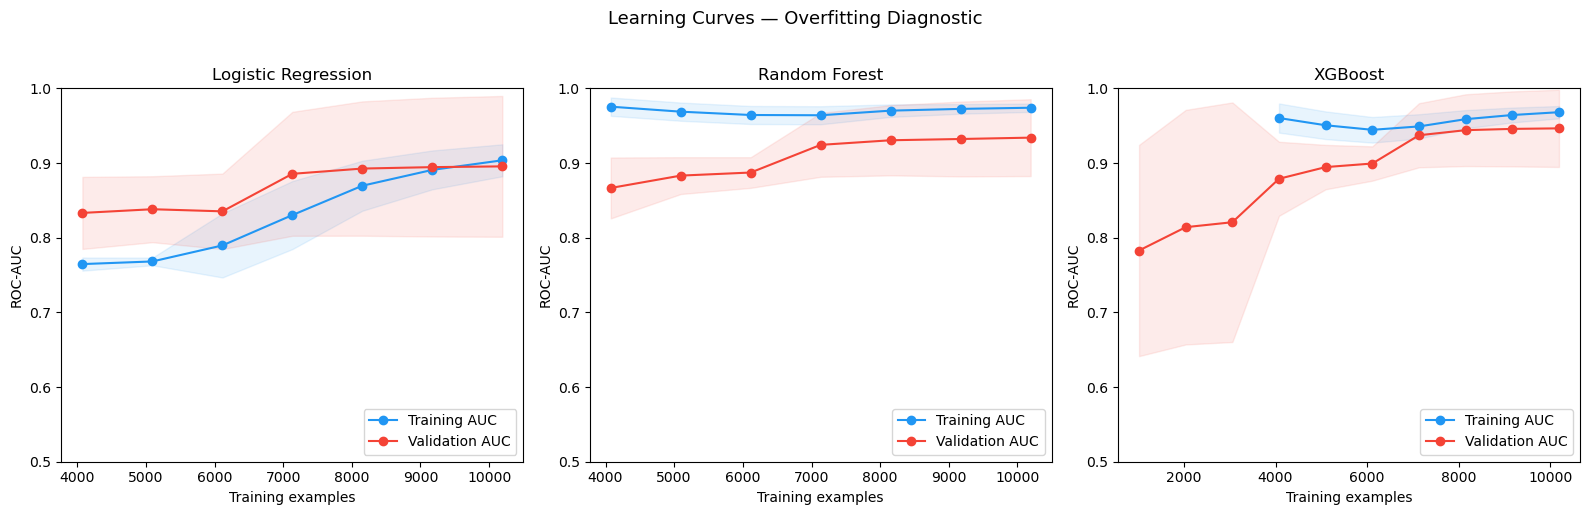

In [35]:
from sklearn.model_selection import learning_curve

def plot_learning_curve(model, X, y, title):
    train_sizes, train_scores, val_scores = learning_curve(
        model, X, y,
        cv=5,
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 10),
        scoring='roc_auc'
    )
    train_mean = train_scores.mean(axis=1)
    val_mean   = val_scores.mean(axis=1)
    train_std  = train_scores.std(axis=1)
    val_std    = val_scores.std(axis=1)

    plt.plot(train_sizes, train_mean, 'o-', color='#2196F3', label='Training AUC')
    plt.plot(train_sizes, val_mean,   'o-', color='#F44336', label='Validation AUC')
    plt.fill_between(train_sizes,
                     train_mean - train_std,
                     train_mean + train_std, alpha=0.1, color='#2196F3')
    plt.fill_between(train_sizes,
                     val_mean - val_std,
                     val_mean + val_std, alpha=0.1, color='#F44336')
    plt.title(title)
    plt.xlabel('Training examples')
    plt.ylabel('ROC-AUC')
    plt.legend(loc='lower right')
    plt.ylim(0.5, 1.0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_lc = [
    (lr_model,  'Logistic Regression'),
    (rf_model,  'Random Forest'),
    (xgb_model, 'XGBoost')
]
for ax, (model, title) in zip(axes, models_lc):
    plt.sca(ax)
    plot_learning_curve(model, X_train_scaled, y_train_bal, title)

plt.suptitle('Learning Curves — Overfitting Diagnostic', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature importance from Random Forest and XGBoost


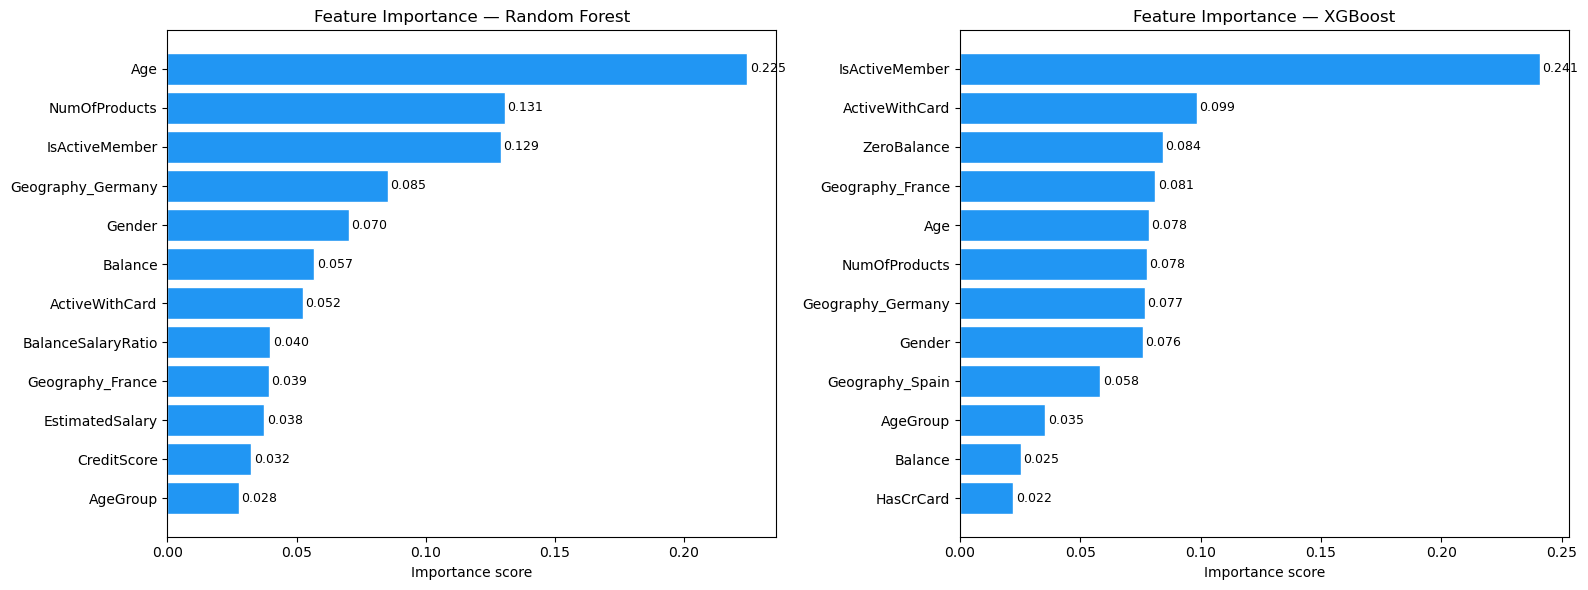

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

feature_names = X.columns.tolist()

for ax, (model, title) in zip(axes, [
    (rf_model,  'Random Forest'),
    (xgb_model, 'XGBoost')
]):
    importances = pd.Series(model.feature_importances_, index=feature_names)
    importances = importances.sort_values(ascending=True).tail(12)
    bars = ax.barh(importances.index, importances.values,
                   color='#2196F3', edgecolor='white')
    ax.set_title(f'Feature Importance — {title}')
    ax.set_xlabel('Importance score')
    for bar, val in zip(bars, importances.values):
        ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# GridSearchCV on XGBoost

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth':     [3, 5, 7],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators':  [100, 200]
}

grid_search = GridSearchCV(
    XGBClassifier(subsample=0.8, colsample_bytree=0.8,
                  use_label_encoder=False, eval_metric='logloss',
                  random_state=42),
    param_grid,
    cv=5,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train_bal)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV AUC:    {grid_search.best_score_:.4f}")

# Retrain with best params
xgb_best = grid_search.best_estimator_
xgb_best_pred  = xgb_best.predict(X_test_scaled)
xgb_best_proba = xgb_best.predict_proba(X_test_scaled)[:, 1]

print("\n=== XGBoost (Tuned) ===")
print(classification_report(y_test, xgb_best_pred, target_names=['Stayed','Churned']))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_best_proba):.4f}")

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200}
Best CV AUC:    0.9547

=== XGBoost (Tuned) ===
              precision    recall  f1-score   support

      Stayed       0.90      0.90      0.90      1593
     Churned       0.61      0.59      0.60       407

    accuracy                           0.84      2000
   macro avg       0.75      0.75      0.75      2000
weighted avg       0.84      0.84      0.84      2000

ROC-AUC: 0.8513


# Confusion matrices

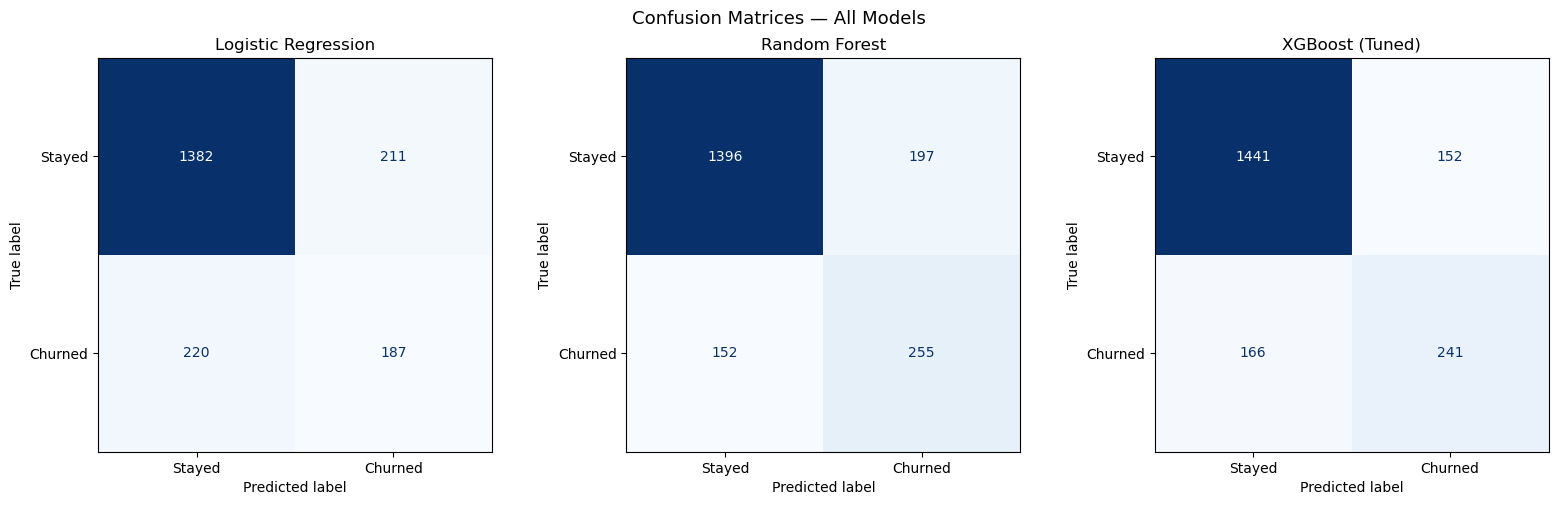

In [39]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_eval = [
    (lr_pred,       'Logistic Regression'),
    (rf_pred,       'Random Forest'),
    (xgb_best_pred, 'XGBoost (Tuned)')
]

for ax, (preds, title) in zip(axes, models_eval):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Stayed', 'Churned'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(title)

plt.suptitle('Confusion Matrices — All Models', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

# Save models for Streamlit deployment

In [40]:
import joblib

joblib.dump(lr_model,  'model_logistic.pkl')
joblib.dump(rf_model,  'model_rf.pkl')
joblib.dump(xgb_best,  'model_xgb.pkl')

print("Models saved ✓")
print("  model_logistic.pkl")
print("  model_rf.pkl")
print("  model_xgb.pkl")

Models saved ✓
  model_logistic.pkl
  model_rf.pkl
  model_xgb.pkl


# Build comprehensive metrics table

In [41]:
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score, roc_auc_score)

def get_metrics(name, y_true, y_pred, y_proba):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred),       4),
        'Precision': round(precision_score(y_true, y_pred),      4),
        'Recall':    round(recall_score(y_true, y_pred),         4),
        'F1 Score':  round(f1_score(y_true, y_pred),             4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_proba),       4),
    }

results = pd.DataFrame([
    get_metrics('Logistic Regression', y_test, lr_pred,       lr_proba),
    get_metrics('Random Forest',       y_test, rf_pred,       rf_proba),
    get_metrics('XGBoost (Tuned)',     y_test, xgb_best_pred, xgb_best_proba),
])

results = results.set_index('Model')
print(results.to_string())

                     Accuracy  Precision  Recall  F1 Score  ROC-AUC
Model                                                              
Logistic Regression    0.7845     0.4698  0.4595    0.4646   0.7491
Random Forest          0.8255     0.5642  0.6265    0.5937   0.8517
XGBoost (Tuned)        0.8410     0.6132  0.5921    0.6025   0.8513


# Grouped bar chart of all metrics

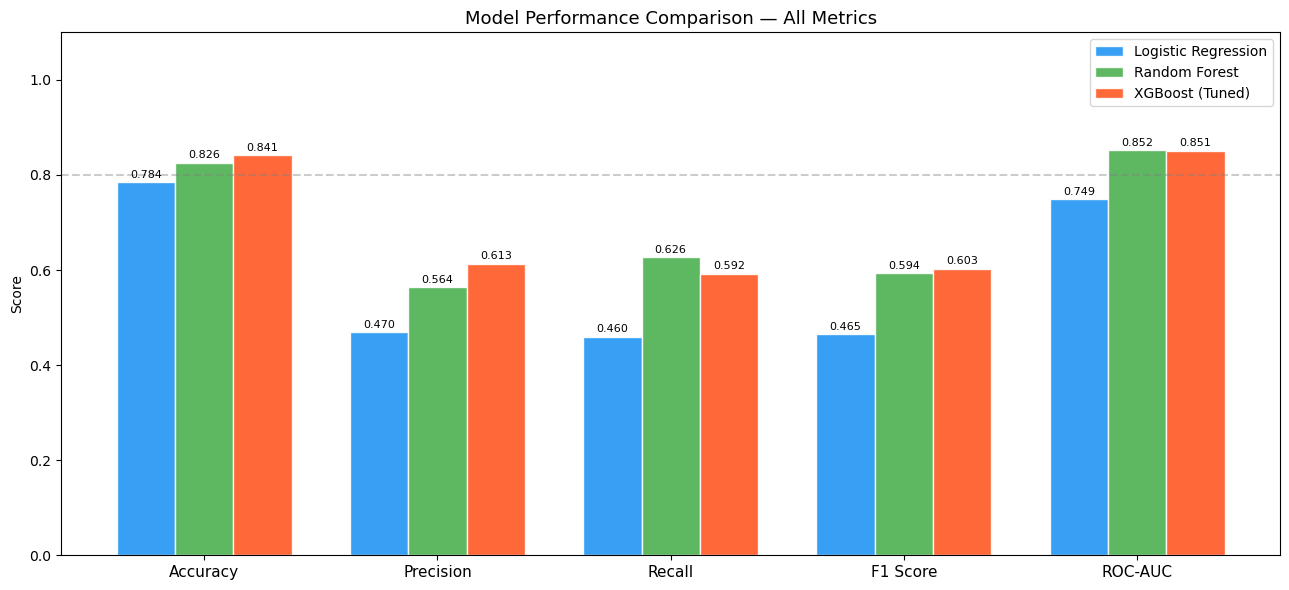

In [42]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'ROC-AUC']
x       = np.arange(len(metrics))
width   = 0.25
colors  = ['#2196F3', '#4CAF50', '#FF5722']

fig, ax = plt.subplots(figsize=(13, 6))

for i, (model_name, row) in enumerate(results.iterrows()):
    bars = ax.bar(x + i * width, [row[m] for m in metrics],
                  width, label=model_name,
                  color=colors[i], edgecolor='white', alpha=0.9)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.005,
                f'{bar.get_height():.3f}',
                ha='center', va='bottom', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score')
ax.set_title('Model Performance Comparison — All Metrics', fontsize=13)
ax.legend()
ax.axhline(y=0.8, color='gray', linestyle='--', alpha=0.4, label='0.8 threshold')
plt.tight_layout()
plt.savefig('model_comparison_bar.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curves

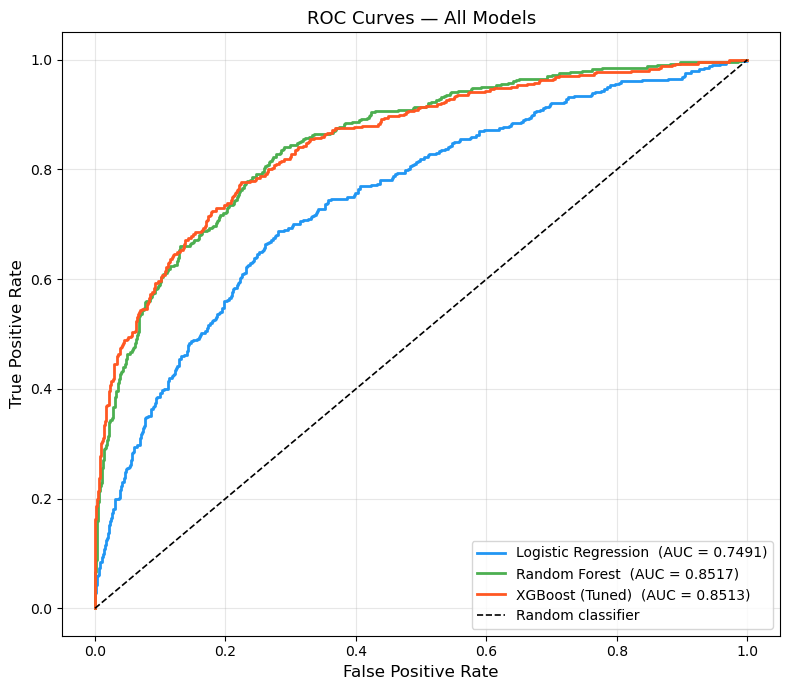

In [43]:
fig, ax = plt.subplots(figsize=(8, 7))

models_roc = [
    (lr_proba,       'Logistic Regression', '#2196F3'),
    (rf_proba,       'Random Forest',       '#4CAF50'),
    (xgb_best_proba, 'XGBoost (Tuned)',     '#FF5722'),
]

for proba, name, colour in models_roc:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax.plot(fpr, tpr, color=colour, lw=2,
            label=f'{name}  (AUC = {auc:.4f})')

# Random baseline
ax.plot([0, 1], [0, 1], 'k--', lw=1.2, label='Random classifier')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate', fontsize=12)
ax.set_title('ROC Curves — All Models', fontsize=13)
ax.legend(loc='lower right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# 5-fold cross-validation on all three models

In [44]:
from sklearn.model_selection import cross_val_score

cv_results = {}

for name, model in [
    ('Logistic Regression', lr_model),
    ('Random Forest',       rf_model),
    ('XGBoost (Tuned)',     xgb_best),
]:
    scores = cross_val_score(model, X_train_scaled, y_train_bal,
                             cv=5, scoring='roc_auc', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}")
    print(f"  Fold AUCs : {np.round(scores, 4)}")
    print(f"  Mean ± Std: {scores.mean():.4f} ± {scores.std():.4f}\n")

Logistic Regression
  Fold AUCs : [0.7139 0.8919 0.9612 0.9556 0.9549]
  Mean ± Std: 0.8955 ± 0.0943

Random Forest
  Fold AUCs : [0.8333 0.9389 0.9665 0.962  0.9691]
  Mean ± Std: 0.9340 ± 0.0514

XGBoost (Tuned)
  Fold AUCs : [0.8608 0.9562 0.9862 0.9844 0.9861]
  Mean ± Std: 0.9547 ± 0.0483



# Boxplot of cross-validation scores

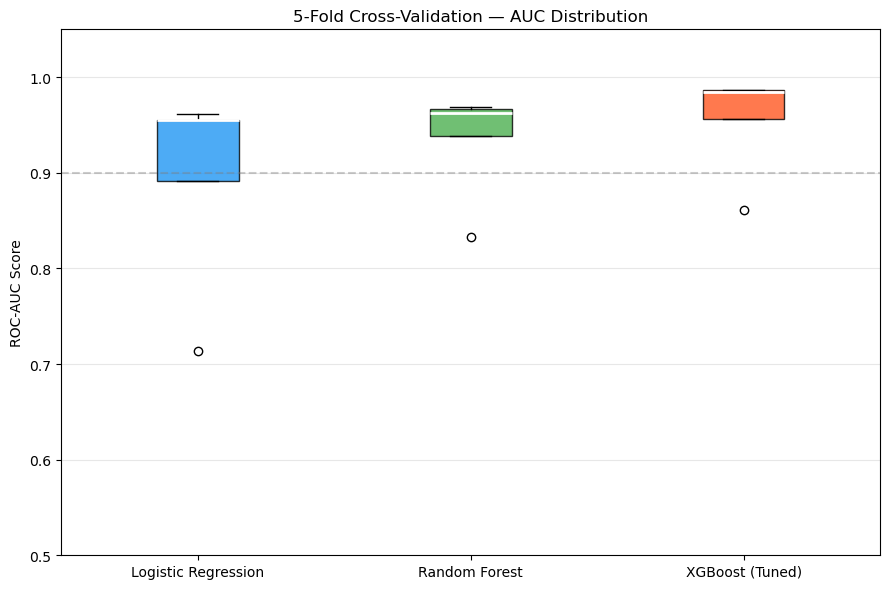

In [45]:
fig, ax = plt.subplots(figsize=(9, 6))

bp = ax.boxplot(cv_results.values(),
                labels=cv_results.keys(),
                patch_artist=True,
                medianprops=dict(color='white', linewidth=2))

for patch, color in zip(bp['boxes'], ['#2196F3', '#4CAF50', '#FF5722']):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_ylabel('ROC-AUC Score')
ax.set_title('5-Fold Cross-Validation — AUC Distribution')
ax.set_ylim(0.5, 1.05)
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.4)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('cross_validation_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

# Precision-Recall curves 

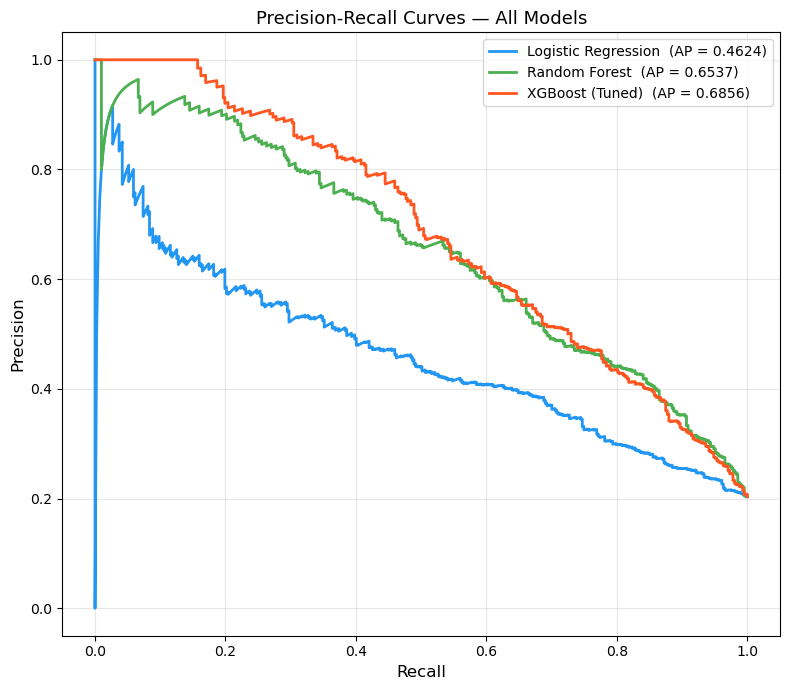

In [46]:
from sklearn.metrics import precision_recall_curve, average_precision_score

fig, ax = plt.subplots(figsize=(8, 7))

for proba, name, colour in models_roc:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    ax.plot(rec, prec, color=colour, lw=2,
            label=f'{name}  (AP = {ap:.4f})')

ax.set_xlabel('Recall', fontsize=12)
ax.set_ylabel('Precision', fontsize=12)
ax.set_title('Precision-Recall Curves — All Models', fontsize=13)
ax.legend(loc='upper right')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# Print final model selection summary

In [48]:
print("=" * 55)
print("       FINAL MODEL SELECTION SUMMARY")
print("=" * 55)

summary = results.copy()
summary['CV Mean AUC'] = [
    cv_results['Logistic Regression'].mean(),
    cv_results['Random Forest'].mean(),
    cv_results['XGBoost (Tuned)'].mean()
]
summary['CV Std'] = [
    cv_results['Logistic Regression'].std(),
    cv_results['Random Forest'].std(),
    cv_results['XGBoost (Tuned)'].std()
]
print(summary[['ROC-AUC', 'F1 Score', 'Recall',
               'CV Mean AUC', 'CV Std']].to_string())
print("\n✓ Selected model: XGBoost (Tuned)")
print("  Reason: Highest ROC-AUC, F1, and CV stability")

       FINAL MODEL SELECTION SUMMARY
                     ROC-AUC  F1 Score  Recall  CV Mean AUC    CV Std
Model                                                                
Logistic Regression   0.7491    0.4646  0.4595     0.895500  0.094287
Random Forest         0.8517    0.5937  0.6265     0.933979  0.051441
XGBoost (Tuned)       0.8513    0.6025  0.5921     0.954739  0.048320

✓ Selected model: XGBoost (Tuned)
  Reason: Highest ROC-AUC, F1, and CV stability


# Save final selected model

In [49]:
joblib.dump(xgb_best, 'final_model.pkl')
print("Final model saved as final_model.pkl ✓")

# Confirm all deployment files exist
import os
files = ['final_model.pkl', 'scaler.pkl', 'feature_names.pkl']
for f in files:
    status = "✓ found" if os.path.exists(f) else "✗ missing"
    print(f"  {f}: {status}")

Final model saved as final_model.pkl ✓
  final_model.pkl: ✓ found
  scaler.pkl: ✓ found
  feature_names.pkl: ✓ found
